## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from EarlyFusion.IntermediateFusionMLP import *
from EarlyFusion.utils import cross_validation_5fold_intermediate_fusion, hyperparameter_tuning

## 2. Concatenation

In [4]:
AUDIO_FEATURES = "/mloscratch/users/gnahas/data/features/acoustic_features_vf.csv"
TAPPING_FEATURES = "/mloscratch/users/clerget/data/csv/tapping_combined_features_session.csv"

audio_features = pd.read_csv(AUDIO_FEATURES)
tapping_features = pd.read_csv(TAPPING_FEATURES)

# Rename 'healthcode' to 'healthCode' for consistency if needed
if 'healthcode' in audio_features.columns and 'healthCode' not in audio_features.columns:
    audio_features = audio_features.rename(columns={'healthcode': 'healthCode'})

if 'healthcode' in tapping_features.columns and 'healthCode' not in TAPPING_FEATURES.columns:
    tapping_features = tapping_features.rename(columns={'healthcode': 'healthCode'})

# Count occurrences of trials per patient in each dataframe
counts_audio = audio_features["healthCode"].value_counts()
counts_tapping = tapping_features["healthCode"].value_counts()

# Consider healthCodes present in both files
shared_healthCodes = counts_audio.index.intersection(counts_tapping.index)

# Helper: minimum count of trials for each patient
min_counts = {code: min(counts_audio[code], counts_tapping[code]) for code in shared_healthCodes}

# Dropping extra audio trials per patient where needed
counts_audio_balanced = (
    audio_features[audio_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Dropping extra tapping trials per patient where needed
counts_tapping_balanced = (
    tapping_features[tapping_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Sort both dataframes by healthCode to ensure alignment
counts_audio_balanced = counts_audio_balanced.sort_values("healthCode").reset_index(drop=True)
counts_tapping_balanced = counts_tapping_balanced.sort_values("healthCode").reset_index(drop=True)

# Verify that there are the same amount of trials in both dataframes
print("Balanced trials count match:", len(counts_audio_balanced) == len(counts_tapping_balanced))

# Verify that healthCodes are properly aligned
print("Columns aligned:", all(
    counts_audio_balanced["healthCode"].values == counts_tapping_balanced["healthCode"].values
))

counts_audio_balanced.to_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_audio.csv", index=False)
counts_tapping_balanced.to_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_tapping.csv", index=False)

/tmp/ipykernel_43180/3681482523.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
/tmp/ipykernel_43180/3681482523.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))


Balanced trials count match: True
Columns aligned: True


In [6]:
audio = pd.read_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_audio.csv")
tapping = pd.read_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_tapping.csv")
merged = pd.read_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/fusion_features.csv")

print(len(audio), len(tapping), len(merged))

14628 14628 14628


## 3. Data Loading

In [2]:
AUDIO_FUSION_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_audio.csv"
TAPPING_FUSION_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/intermediate_features_tapping.csv"
LABELS = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/paired_healthcode.csv"
TRAIN_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_train.csv"
VAL_TEST_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"

## 4. Cross-Validation & Hyperparameter Tuning 

Using the given 5-folds, we call a hyperparameter tuning fucntion which itself calls our cross-validation function. In this way, we find the best possible early fusion MLP.

In [5]:
results = cross_validation_5fold_intermediate_fusion(
    audio_features_csv=AUDIO_FUSION_FEATURES,
    tapping_features_csv=TAPPING_FUSION_FEATURES,
    labels_csv=LABELS,
    train_folds_csv=TRAIN_FOLDS,
    val_test_folds_csv=VAL_TEST_FOLDS,
    hidden_dims = [64, 32],
    audio_branch= {"output_dim": 64, "hidden_dims": [256, 128]},
    tapping_branch= {"output_dim": 64, "hidden_dims": [32]},
    dropout= 0.7,
    class_weight = 2.85,
    num_epochs = 150,
    learning_rate = 0.001,
    verbose = True,
    weight_decay=0.001       
)

Loaded audio features: (14628, 157)
  Columns: ['filename', 'healthCode', 'record_id', 'mfcc_1_mean', 'mfcc_1_std']...
Loaded tapping features: (14628, 15)
  Columns: ['mean_dt', 'std_dt', 'total_taps', 'mean_x', 'mean_y']...
Loaded labels: (532, 3)
  Columns: ['healthCode', 'label_PD', 'modality']
Train folds: (1380, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
Val+Test folds: (1064, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
  - Validation folds: (532, 3)
  - Test folds: (532, 3)
Audio features after merging with labels: (14628, 158)
Tapping features after merging with labels: (14628, 16)
Audio features after filtering to 5-fold healthcodes: (14628, 158)
Tapping features after filtering to 5-fold healthcodes: (14628, 16)
Number of audio features: 154
Audio feature columns: ['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean']... (showing first 5)
Number of tapping features: 13
Tapping feature columns: ['mean_dt', 'std_dt', 'total_taps', '

## 5. Results Visualization

Using matplotlib, we visualize the results of our best model. We take a look at the following metrics:

- Confusion Metrics
- Test AUC ROC Score
- Test F1 Score
- Test Accuracy

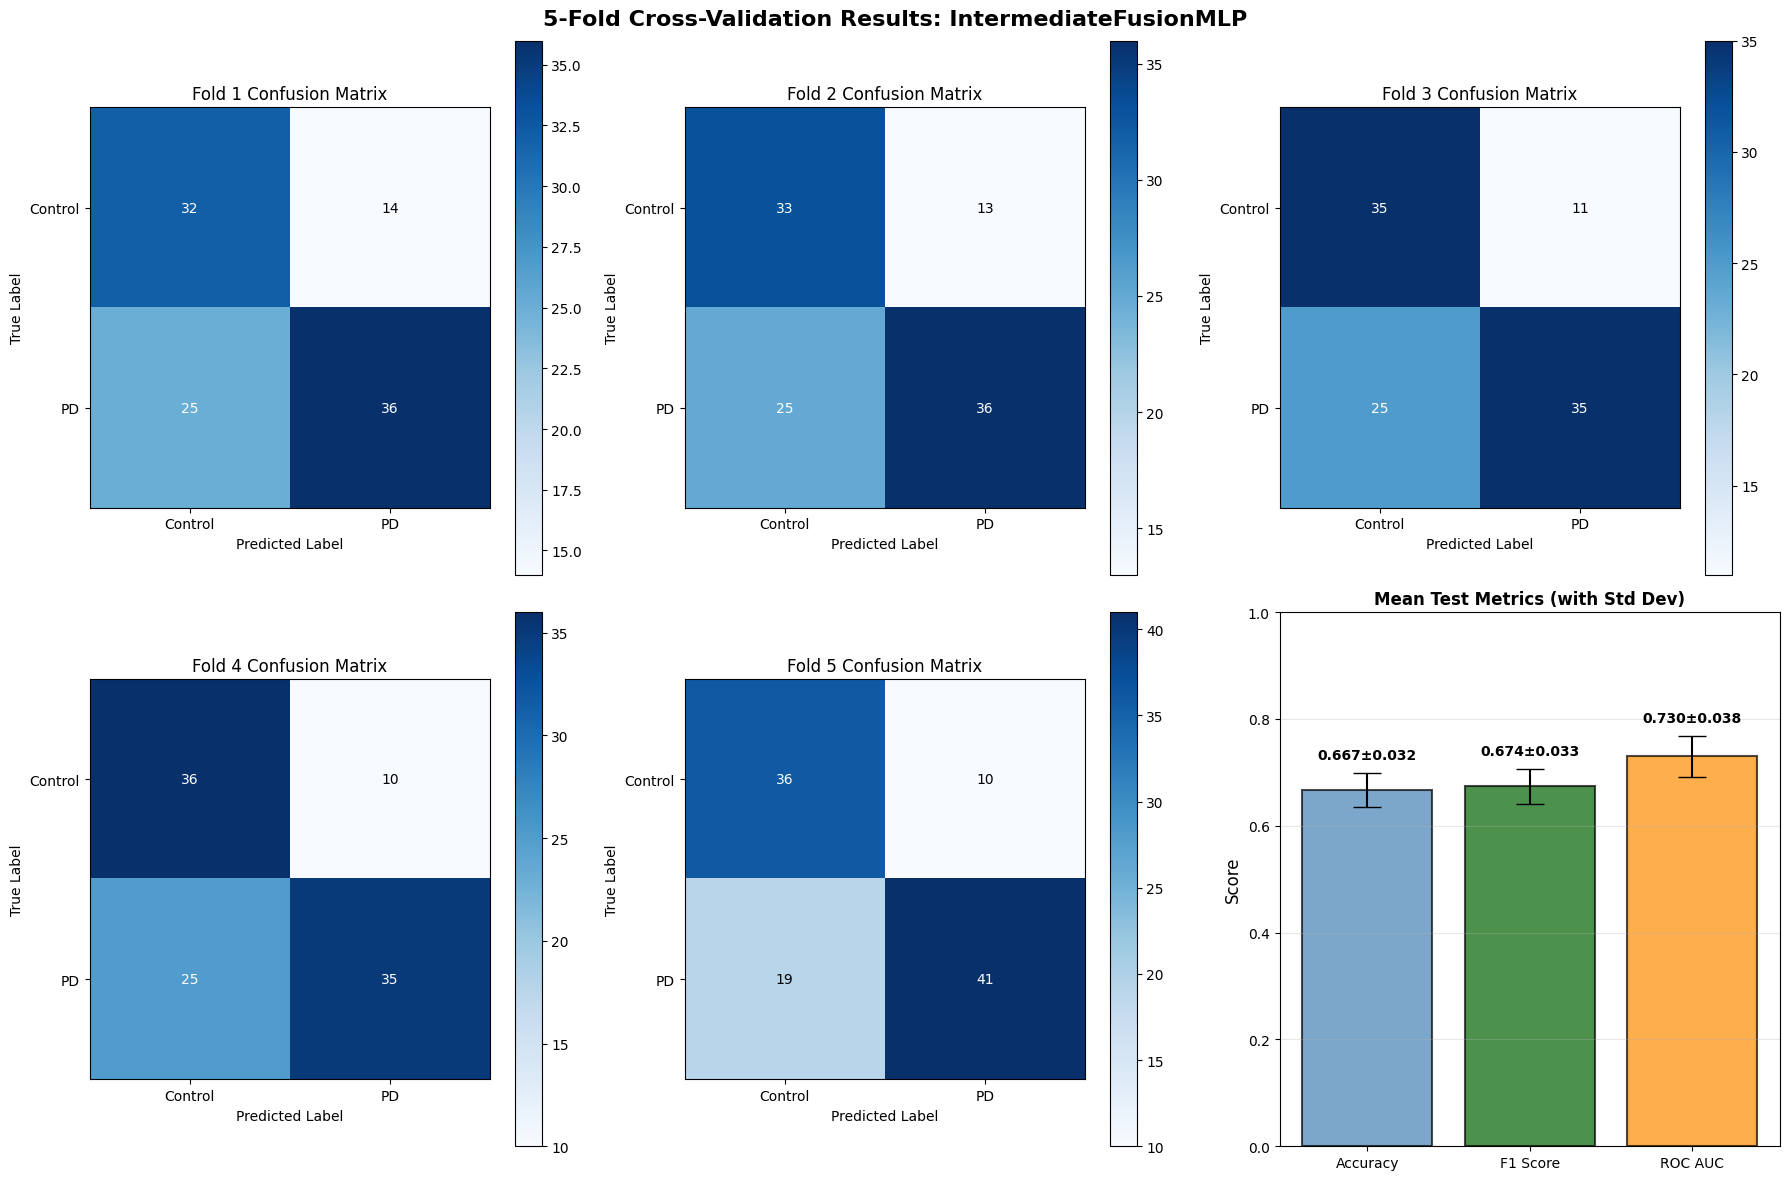


Summary Statistics:
Test Accuracy: 0.6674 ± 0.0318
Test F1 Score: 0.6738 ± 0.0330
Test ROC AUC:  0.7300 ± 0.0383


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('5-Fold Cross-Validation Results: IntermediateFusionMLP', fontsize=16, fontweight='bold')

# Plot confusion matrices for each fold
for i, cm in enumerate(results['confusion_matrices']):
    if i < 5:  # We have 5 folds
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Plot confusion matrix as heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Fold {i + 1} Confusion Matrix')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, format(cm[row_idx, col_idx], 'd'),
                       ha="center", va="center",
                       color="white" if cm[row_idx, col_idx] > thresh else "black")
        
        # Set ticks
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Control', 'PD'])
        ax.set_yticklabels(['Control', 'PD'])

# Plot mean metrics with error bars in the last subplot
ax = axes[1, 2]
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
means = [results['mean_test_acc'], results['mean_test_f1'], results['mean_test_roc_auc']]
stds = [results['std_test_acc'], results['std_test_f1'], results['std_test_roc_auc']]

x_pos = np.arange(len(metrics))
bars = ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
              color=['steelblue', 'darkgreen', 'darkorange'], 
              ecolor='black', capsize=10, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Test Metrics (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Test Accuracy: {results['mean_test_acc']:.4f} ± {results['std_test_acc']:.4f}")
print(f"Test F1 Score: {results['mean_test_f1']:.4f} ± {results['std_test_f1']:.4f}")
print(f"Test ROC AUC:  {results['mean_test_roc_auc']:.4f} ± {results['std_test_roc_auc']:.4f}")